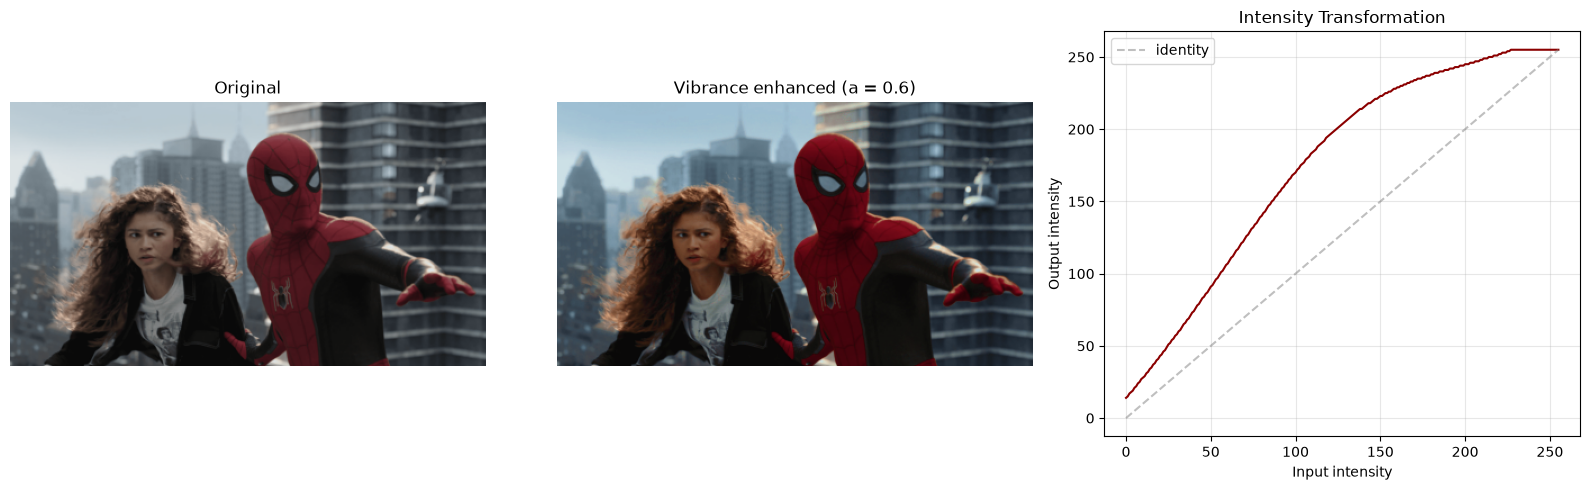

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im_bgr = cv.imread(r'D:\Image processing and Computer Vision\Images\spiderman.png')
assert im_bgr is not None

hsv = cv.cvtColor(im_bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

sigma = 70

def vibrance_lut(a, sigma=70):
    x = np.arange(256, dtype=np.float64)
    boost = a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    f = np.minimum(x + boost, 255)
    return np.clip(f, 0, 255).astype(np.uint8)

a = 0.6   
lut = vibrance_lut(a, sigma)
s_boosted = cv.LUT(s, lut)

hsv_boosted = cv.merge([h, s_boosted, v])
im_boosted_bgr = cv.cvtColor(hsv_boosted, cv.COLOR_HSV2BGR)

im_rgb = cv.cvtColor(im_bgr, cv.COLOR_BGR2RGB)
im_boosted_rgb = cv.cvtColor(im_boosted_bgr, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(im_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(im_boosted_rgb)
axes[1].set_title(f"Vibrance enhanced (a = {a})")
axes[1].axis("off")

axes[2].plot(np.arange(256), lut, color="darkred")
axes[2].plot(np.arange(256), np.arange(256), color="gray", linestyle="--", alpha=0.5, label="identity")
axes[2].set_title("Intensity Transformation")
axes[2].set_xlabel("Input intensity")
axes[2].set_ylabel("Output intensity")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()